# 04. Валидация результатов

**Проверки:**
1. Hold-out метрики модели (из 03)
2. GKH cross-check: сравнение predicted height vs gkh_floor_count * 3.0
3. OSM cross-check: сравнение predicted height vs OSM (building:levels * 3.0)
3. Распределение ошибок по пространству
4. Sanity checks: физически разумные значения

In [1]:
from utils import CONFIG, load_gdf, compute_height_metrics
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

sns.set_theme(style='whitegrid', palette='Set2')
%matplotlib inline

# Загрузка
gdf = load_gdf('./data/final.parquet')
gdf_proj = gdf.to_crs(CONFIG['crs_projected'])

with open('./data/xgb_model.pkl', 'rb') as f:
    model = pickle.load(f)

print(f"Загружено: {len(gdf):,} зданий")
print(f"  source_b: {(gdf['height_source'] == 'source_b').sum():,}")
print(f"  ml_predicted: {(gdf['height_source'] == 'ml_predicted').sum():,}")

Загружено: 196,806 зданий
  source_b: 160,749
  ml_predicted: 36,057


## 1. GKH Cross-Check

Для ~10% зданий с данными ЖКХ (этажность) проверяем: `predicted_height ~ gkh_floor_max * 3.0 м`

Зданий с данными ЖКХ: 24,599

Наша высота vs GKH-оценка (floor*3м):
  MAE: 3.656
  RMSE: 7.087
  R2: 0.764
  pct_under_3m: 40.790
  pct_under_5m: 77.881
  p95_error: 12.000
  n_samples: 24599


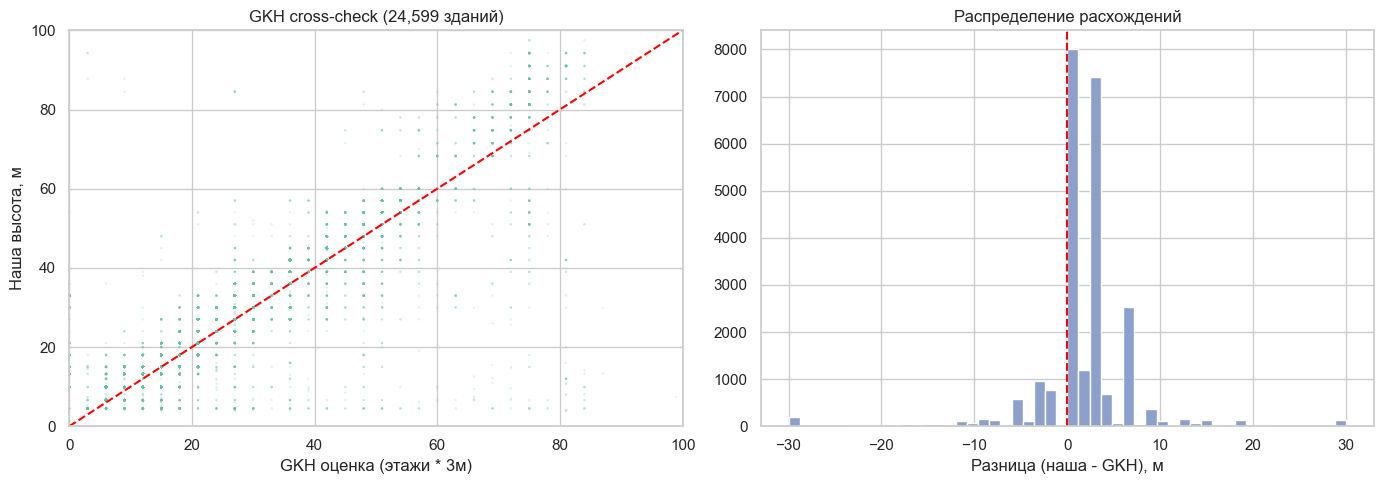

In [2]:
# GKH cross-check
gkh_mask = pd.to_numeric(gdf['gkh_floor_max'], errors='coerce').notna()
gdf_gkh = gdf[gkh_mask].copy()
gdf_gkh['gkh_floors'] = pd.to_numeric(gdf_gkh['gkh_floor_max'], errors='coerce')
gdf_gkh['gkh_estimated_height'] = gdf_gkh['gkh_floors'] * 3.0

print(f"Зданий с данными ЖКХ: {len(gdf_gkh):,}")

# Метрики: наша высота vs GKH-оценка
metrics_gkh = compute_height_metrics(
    gdf_gkh['gkh_estimated_height'].values,
    gdf_gkh['height'].values
)
print(f"\nНаша высота vs GKH-оценка (floor*3м):")
for k, v in metrics_gkh.items():
    print(f"  {k}: {v:.3f}" if isinstance(v, float) else f"  {k}: {v}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: наша высота vs GKH
axes[0].scatter(gdf_gkh['gkh_estimated_height'], gdf_gkh['height'], s=3, alpha=0.2, edgecolors='none')
axes[0].plot([0, 100], [0, 100], 'r--')
axes[0].set_xlabel('GKH оценка (этажи * 3м)')
axes[0].set_ylabel('Наша высота, м')
axes[0].set_title(f'GKH cross-check ({len(gdf_gkh):,} зданий)')
axes[0].set_xlim(0, 100)
axes[0].set_ylim(0, 100)

# Распределение расхождений
diff = gdf_gkh['height'] - gdf_gkh['gkh_estimated_height']
axes[1].hist(diff.clip(-30, 30), bins=50, edgecolor='white', color='#8da0cb')
axes[1].axvline(0, color='red', ls='--')
axes[1].set_xlabel('Разница (наша - GKH), м')
axes[1].set_title('Распределение расхождений')

plt.tight_layout()
plt.show()

## 2. Пространственный анализ ошибок

Проверяем: нет ли систематического bias в отдельных районах?

## 1.5 Адресная валидация

Для matched зданий, где есть адрес из обоих источников, проверяем совпадение: `gkh_address` (А) vs `name_street + number` (Б).

In [3]:
# Адресная валидация матчинга
matched = gdf[gdf['match_type'] == 'matched'].copy()

# Есть ли адреса в обоих источниках?
has_addr_a = matched['gkh_address'].notna() & (matched['gkh_address'] != 'None') & (matched['gkh_address'] != 'nan')
has_addr_b = matched['name_street'].notna() & (matched['name_street'] != 'None') & (matched['name_street'] != 'nan')
both_addr = has_addr_a & has_addr_b

print(f"Matched зданий: {len(matched):,}")
print(f"  С адресом А (gkh_address): {has_addr_a.sum():,}")
print(f"  С адресом Б (name_street):  {has_addr_b.sum():,}")
print(f"  С адресом в обоих: {both_addr.sum():,}")

if both_addr.sum() > 0:
    df_addr = matched[both_addr].copy()
    
    # Нормализуем адрес Б: "улица + номер"
    df_addr['addr_b'] = (
        df_addr['name_street'].astype(str).str.strip().str.lower() + ' ' +
        df_addr['number'].astype(str).str.strip()
    )
    
    # Нормализуем адрес А: извлекаем улицу и номер
    df_addr['addr_a_clean'] = df_addr['gkh_address'].astype(str).str.strip().str.lower()
    
    # Простая проверка: содержит ли addr_a название улицы из Б?
    def street_match(row):
        addr_a = str(row['addr_a_clean'])
        street_b = str(row['name_street']).strip().lower()
        if len(street_b) < 3:
            return None  # слишком короткое — не проверяем
        return street_b in addr_a
    
    df_addr['street_match'] = df_addr.apply(street_match, axis=1)
    
    valid = df_addr['street_match'].notna()
    matches = df_addr.loc[valid, 'street_match']
    
    n_checked = valid.sum()
    n_match = matches.sum()
    n_mismatch = n_checked - n_match
    
    print(f"\nАдресная проверка (улица Б содержится в адресе А):")
    print(f"  Проверено: {n_checked:,}")
    print(f"  Совпали:   {n_match:,} ({n_match/n_checked*100:.1f}%)")
    print(f"  Не совпали: {n_mismatch:,} ({n_mismatch/n_checked*100:.1f}%)")
    
    # Примеры несовпадений
    mismatches = df_addr[valid & ~df_addr['street_match']]
    if len(mismatches) > 0:
        print(f"\nПримеры несовпадений (первые 10):")
        for _, row in mismatches.head(10).iterrows():
            print(f"  А: {row['gkh_address']}")
            print(f"  Б: {row['name_street']} {row['number']}")
            print()
else:
    print("Нет зданий с адресами в обоих источниках")

Matched зданий: 137,579
  С адресом А (gkh_address): 25,316
  С адресом Б (name_street):  86,353
  С адресом в обоих: 24,840

Адресная проверка (улица Б содержится в адресе А):
  Проверено: 24,840
  Совпали:   21,933 (88.3%)
  Не совпали: 2,907 (11.7%)

Примеры несовпадений (первые 10):
  А: г. Санкт-Петербург, ул. Опочинина, д. 15/18, стр. А
  Б: Гаванская 8.0

  А: г. Санкт-Петербург, линия. 2-я В.О., д. 49, лит. Б
  Б: 1-я В.О. 58.0

  А: г. Санкт-Петербург, линия. 2-я В.О., д. 49, лит. Б
  Б: Магдалинский 1.0

  А: г. Санкт-Петербург, линия. 2-я В.О., д. 49, лит. Б
  Б: 1-я В.О. 58.0

  А: г. Санкт-Петербург, линия. 2-я В.О., д. 49, лит. Б
  Б: 1-я В.О. 58.0

  А: г. Санкт-Петербург, линия. 2-я В.О., д. 49, лит. Б
  Б: 1-я В.О. 60.0

  А: г. Санкт-Петербург, ул. Воскова, д. 18/10, лит. А
  Б: Саблинская 10.0

  А: г. Санкт-Петербург, ул. Воскова, д. 18/10, лит. А
  Б: Кропоткина 20.0

  А: г. Санкт-Петербург, пр-кт. Московский, д. 183-185
  Б: Варшавская 66.0

  А: г. Санкт-Петербу

/var/folders/qd/n49svq751492jzpbmv77z3cm0000gn/T/ipykernel_98356/2861177885.py:13: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  sample_b.geometry.centroid.x, sample_b.geometry.centroid.y,
/var/folders/qd/n49svq751492jzpbmv77z3cm0000gn/T/ipykernel_98356/2861177885.py:23: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  sample_ml.geometry.centroid.x, sample_ml.geometry.centroid.y,


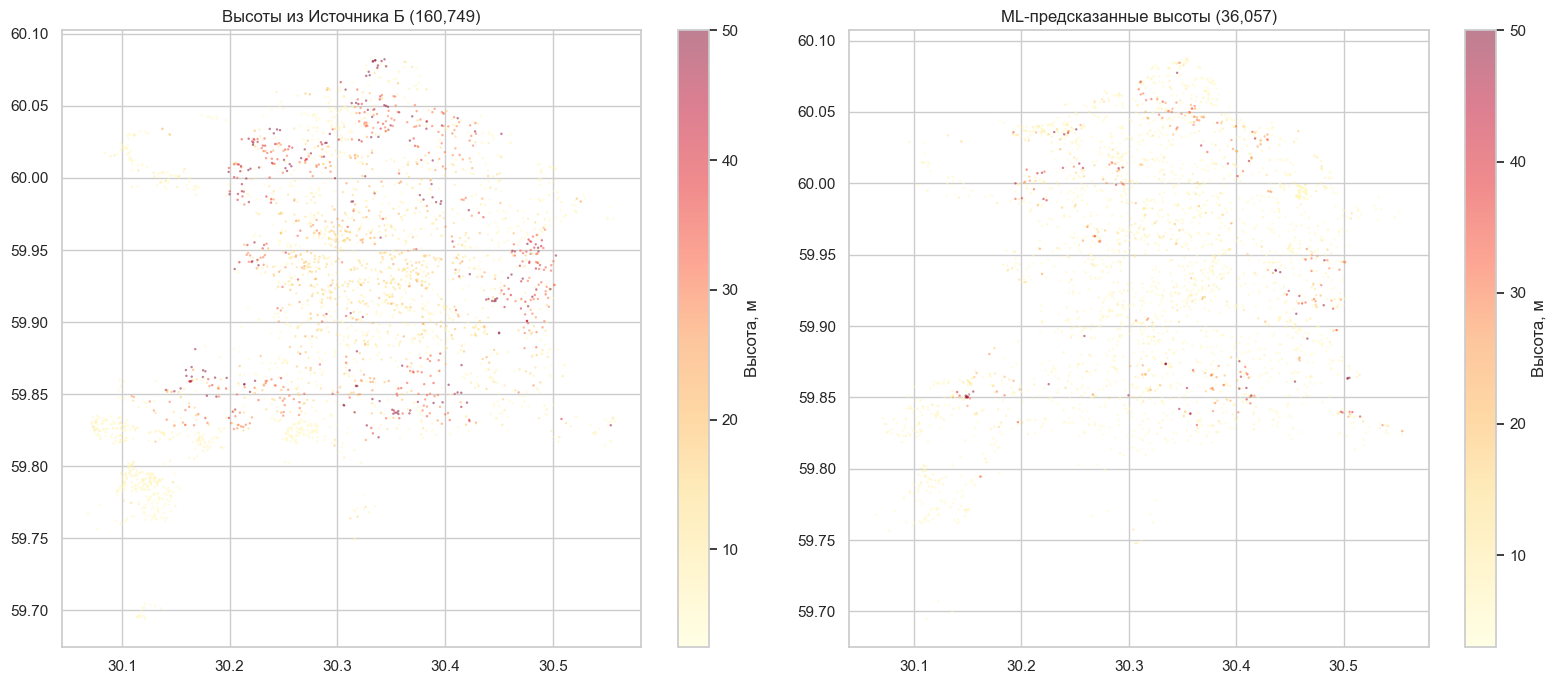

In [4]:
# Для зданий с высотой из Б и ML-предсказанных
gdf_b_buildings = gdf[gdf['height_source'] == 'source_b'].copy()
ml_buildings = gdf[gdf['height_source'] == 'ml_predicted'].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

gdf_b_geo = gdf_b_buildings.to_crs(CONFIG['crs_geo'])
ml_geo = ml_buildings.to_crs(CONFIG['crs_geo'])

# Высоты из Б
sample_b = gdf_b_geo.sample(min(3000, len(gdf_b_geo)), random_state=42)
sc1 = axes[0].scatter(
    sample_b.geometry.centroid.x, sample_b.geometry.centroid.y,
    c=sample_b['height'].clip(upper=50), s=3, alpha=0.5, cmap='YlOrRd', edgecolors='none'
)
plt.colorbar(sc1, ax=axes[0], label='Высота, м')
axes[0].set_title(f'Высоты из Источника Б ({len(gdf_b_buildings):,})')

# Предсказанные высоты
if len(ml_geo) > 0:
    sample_ml = ml_geo.sample(min(3000, len(ml_geo)), random_state=42)
    sc2 = axes[1].scatter(
        sample_ml.geometry.centroid.x, sample_ml.geometry.centroid.y,
        c=sample_ml['height'].clip(upper=50), s=3, alpha=0.5, cmap='YlOrRd', edgecolors='none'
    )
    plt.colorbar(sc2, ax=axes[1], label='Высота, м')
axes[1].set_title(f'ML-предсказанные высоты ({len(ml_buildings):,})')

plt.tight_layout()
plt.show()

## 3. Sanity Checks

## 2.5 OSM Cross-Check (внешний независимый источник)

OpenStreetMap содержит тег `building:levels` для 49% зданий СПб (32,545 из 66,304). Сравниваем нашу высоту с `building_levels * 3.0 м`.

Загрузка из кэша: ./data/osm_buildings_spb.csv
OSM зданий с этажностью: 32,385
Сопоставлено с unified: 30,737

=== OSM Cross-Check (30,737 зданий) ===
Наша высота vs OSM (building:levels * 3м):
  MAE: 3.127
  RMSE: 6.678
  R2: 0.708
  pct_under_3m: 63.103
  pct_under_5m: 85.936
  p95_error: 9.000
  n_samples: 30737

  source_b (26,225): MAE=2.86, %<3m=61.9%, %<5m=86.4%

  ml_predicted (4,512): MAE=4.68, %<3m=70.3%, %<5m=83.0%


/var/folders/qd/n49svq751492jzpbmv77z3cm0000gn/T/ipykernel_98356/460184407.py:56: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  our_centroids = np.column_stack([gdf_geo.geometry.centroid.x, gdf_geo.geometry.centroid.y])


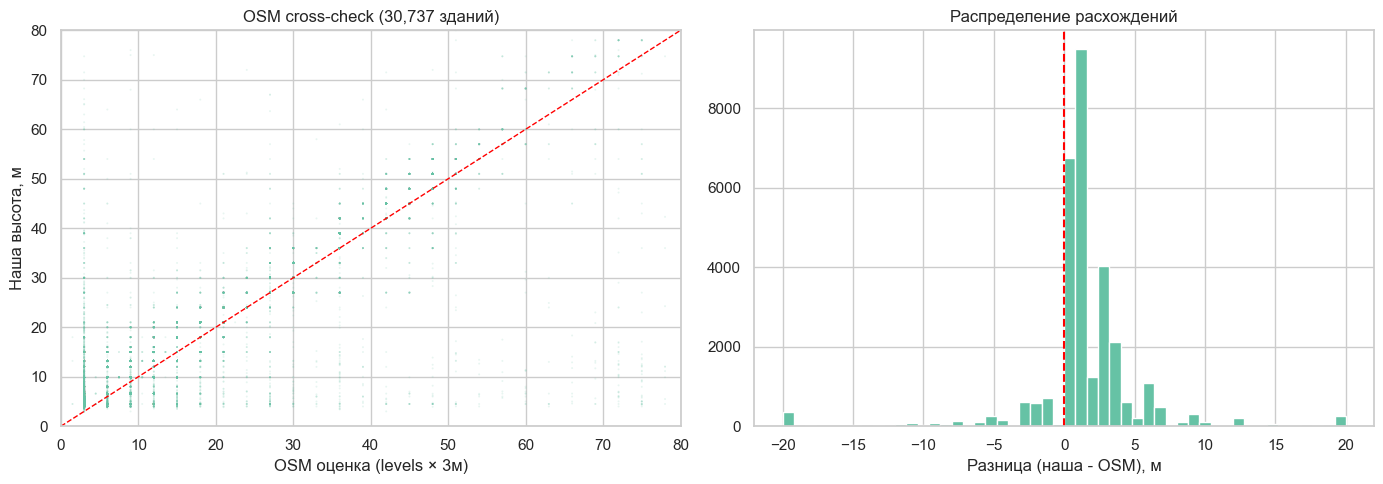

In [5]:
import requests
import os
from scipy.spatial import cKDTree

# === 1. Загрузка данных из OSM ===
osm_csv_path = './data/osm_buildings_spb.csv'

if os.path.exists(osm_csv_path):
    # Используем ранее скачанный файл
    print(f"Загрузка из кэша: {osm_csv_path}")
    df_osm = pd.read_csv(osm_csv_path)
    df_osm['osm_height_est'] = pd.to_numeric(df_osm.get('levels_num', df_osm.get('building_levels')), errors='coerce') * 3.0
else:
    # Запрос к Overpass API (бесплатно, без ключа)
    print("Запрос к Overpass API...")
    query = """
    [out:json][timeout:180];
    way["building"]["building:levels"](59.85,30.15,60.05,30.55);
    out center;
    """
    try:
        r = requests.get("https://overpass-api.de/api/interpreter", params={"data": query}, timeout=200)
        r.raise_for_status()
        osm_data = r.json()
        osm_elements = osm_data.get('elements', [])
        print(f"Получено: {len(osm_elements):,}")
        
        osm_records = []
        for el in osm_elements:
            tags = el.get('tags', {})
            center = el.get('center', {})
            if center:
                try:
                    levels = float(tags.get('building:levels', 0))
                    if levels > 0:
                        osm_records.append({
                            'lat': center['lat'], 'lon': center['lon'],
                            'levels_num': levels, 'osm_height_est': levels * 3.0,
                        })
                except: pass
        
        df_osm = pd.DataFrame(osm_records)
        df_osm.to_csv(osm_csv_path, index=False)
        print(f"Сохранено: {osm_csv_path}")
    except Exception as e:
        print(f"Ошибка Overpass API: {e}")
        print("Попробуйте перезапустить ячейку через минуту (rate limit)")
        df_osm = pd.DataFrame()

if len(df_osm) > 0:
    df_osm = df_osm[df_osm['osm_height_est'].notna() & (df_osm['osm_height_est'] > 0)]
    print(f"OSM зданий с этажностью: {len(df_osm):,}")
    
    # === 2. Spatial join с unified ===
    gdf_geo = gdf.to_crs('EPSG:4326')
    our_centroids = np.column_stack([gdf_geo.geometry.centroid.x, gdf_geo.geometry.centroid.y])
    osm_coords = df_osm[['lon', 'lat']].values
    
    tree = cKDTree(our_centroids)
    dists, indices = tree.query(osm_coords, k=1)
    
    MAX_DIST_DEG = 0.0003  # ~30м
    matched_mask = dists < MAX_DIST_DEG
    
    df_cmp = df_osm[matched_mask].copy()
    df_cmp['our_idx'] = indices[matched_mask]
    df_cmp['our_height'] = gdf_geo.iloc[df_cmp['our_idx'].values]['height'].values
    df_cmp['our_source'] = gdf_geo.iloc[df_cmp['our_idx'].values]['height_source'].values
    df_cmp = df_cmp[df_cmp['our_height'].notna()]
    
    print(f"Сопоставлено с unified: {len(df_cmp):,}")
    
    # === 3. Метрики ===
    metrics_osm = compute_height_metrics(df_cmp['osm_height_est'].values, df_cmp['our_height'].values)
    
    print(f"\n=== OSM Cross-Check ({len(df_cmp):,} зданий) ===")
    print(f"Наша высота vs OSM (building:levels * 3м):")
    for k, v in metrics_osm.items():
        print(f"  {k}: {v:.3f}" if isinstance(v, float) else f"  {k}: {v}")
    
    for src in ['source_b', 'ml_predicted']:
        sub = df_cmp[df_cmp['our_source'] == src]
        if len(sub) > 50:
            m = compute_height_metrics(sub['osm_height_est'].values, sub['our_height'].values)
            print(f"\n  {src} ({len(sub):,}): MAE={m['MAE']:.2f}, %<3m={m['pct_under_3m']:.1f}%, %<5m={m['pct_under_5m']:.1f}%")
    
    # === 4. Графики ===
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].scatter(df_cmp['osm_height_est'], df_cmp['our_height'], s=2, alpha=0.15, edgecolors='none')
    axes[0].plot([0, 100], [0, 100], 'r--', lw=1)
    axes[0].set_xlabel('OSM оценка (levels × 3м)')
    axes[0].set_ylabel('Наша высота, м')
    axes[0].set_title(f'OSM cross-check ({len(df_cmp):,} зданий)')
    axes[0].set_xlim(0, 80); axes[0].set_ylim(0, 80)
    
    diff_osm = df_cmp['our_height'].values - df_cmp['osm_height_est'].values
    axes[1].hist(np.clip(diff_osm, -20, 20), bins=50, edgecolor='white', color='#66c2a5')
    axes[1].axvline(0, color='red', ls='--')
    axes[1].set_xlabel('Разница (наша - OSM), м')
    axes[1].set_title('Распределение расхождений')
    
    plt.tight_layout()
    plt.show()
else:
    print("OSM данные недоступны. Пропускаем.")

In [6]:
print("=== SANITY CHECKS ===\n")

# 1. Все здания имеют высоту
all_have_height = gdf['height'].notna().all()
print(f"[{'OK' if all_have_height else 'FAIL'}] Все {len(gdf):,} зданий имеют высоту")

# 2. Высота в разумных пределах
print(f"[{'OK' if gdf['height'].min() >= 0 else 'WARN'}] Минимальная высота: {gdf['height'].min():.1f} м")
print(f"[{'OK' if gdf['height'].max() <= 500 else 'WARN'}] Максимальная высота: {gdf['height'].max():.1f} м")

# 3. Высокие здания
n_over_100 = (gdf['height'] > 100).sum()
print(f"[INFO] Зданий выше 100м: {n_over_100}")

# 4. Средняя высота по типу
print(f"\nСредняя высота по match_type:")
print(gdf.groupby('match_type')['height'].agg(['mean', 'median', 'count']).round(1))

# 5. Средняя высота по source
print(f"\nСредняя высота по height_source:")
print(gdf.groupby('height_source')['height'].agg(['mean', 'median', 'count']).round(1))

=== SANITY CHECKS ===

[OK] Все 196,806 зданий имеют высоту
[OK] Минимальная высота: 2.0 м
[OK] Максимальная высота: 462.0 м
[INFO] Зданий выше 100м: 20

Средняя высота по match_type:
            mean  median   count
match_type                      
matched     16.2     9.9  137579
only_a       8.3     5.1   36008
only_b       6.0     4.5   23219

Средняя высота по height_source:
               mean  median   count
height_source                      
ml_predicted    8.3     5.1   36057
source_b       14.7     6.6  160749


## 4. Итоговая сводка

In [7]:
print("=" * 60)
print("ИТОГОВАЯ СВОДКА ВАЛИДАЦИИ")
print("=" * 60)

print(f"\n1. ПОЛНОТА:")
print(f"   Всего зданий: {len(gdf):,}")
print(f"   С высотой из Б: {(gdf['height_source'] == 'source_b').sum():,}")
print(f"   С ML-предсказанием: {(gdf['height_source'] == 'ml_predicted').sum():,}")
print(f"   Покрытие: 100%")

print(f"\n2. ТОЧНОСТЬ (hold-out test):")
print(f"   (см. метрики из 03_height_model)")

print(f"\n3. GKH CROSS-CHECK:")
if len(gdf_gkh) > 0:
    for k, v in metrics_gkh.items():
        if isinstance(v, float):
            print(f"   {k}: {v:.2f}")
            
print(f"\n4. OSM Cross-Check:")
for k, v in metrics_osm.items():
    print(f"  {k}: {v:.3f}" if isinstance(v, float) else f"  {k}: {v}")

print(f"\n4. ФИЗИЧЕСКАЯ РАЗУМНОСТЬ:")
print(f"   Высота [min, max]: [{gdf['height'].min():.1f}, {gdf['height'].max():.1f}] м")
print(f"   Медиана: {gdf['height'].median():.1f} м")
print(f"   Зданий < 3м: {(gdf['height'] < 3).sum():,}")
print(f"   Зданий > 100м: {(gdf['height'] > 100).sum():,}")

ИТОГОВАЯ СВОДКА ВАЛИДАЦИИ

1. ПОЛНОТА:
   Всего зданий: 196,806
   С высотой из Б: 160,749
   С ML-предсказанием: 36,057
   Покрытие: 100%

2. ТОЧНОСТЬ (hold-out test):
   (см. метрики из 03_height_model)

3. GKH CROSS-CHECK:
   MAE: 3.66
   RMSE: 7.09
   R2: 0.76
   pct_under_3m: 40.79
   pct_under_5m: 77.88
   p95_error: 12.00

4. OSM Cross-Check:
  MAE: 3.127
  RMSE: 6.678
  R2: 0.708
  pct_under_3m: 63.103
  pct_under_5m: 85.936
  p95_error: 9.000
  n_samples: 30737

4. ФИЗИЧЕСКАЯ РАЗУМНОСТЬ:
   Высота [min, max]: [2.0, 462.0] м
   Медиана: 6.6 м
   Зданий < 3м: 18
   Зданий > 100м: 20
